**Por que estatística é importante em machine learning?**

Um modelo aprende padrões a partir de dados, isso difere da programação comum em que o humano insere REGRAS DETERMINADAS padrões para um programa realizar uma tarefa.

A estatística é ferramenta para:
- Para entender os dados antes
- Percebermos e resolvermos problemas como valores estranhos ou extremos, dados faltantes ou mal registrados
- Comparar previsão com o valor real
- Analisar o quanto determinado resultado é confiável
- Evitar conclusões preciptadas sobre o que modelo aprendeu

**Analise exploratória e validação estatisitica**

Por que?
Conhecer os dados antes e fazer uso da estatística nos permite uma orientação melhor sobre o modelo
Modelos complexos para problemas simples ou modelos simples para problemas complexos geram perda de tempo, recurso e consequentemente valor no desenvolvimento de um projeto de IA

**Aplicação**
Vamos explorar a base de dados, *base_imoveis.csv*
Primeiro começamos lendo a base para criar o dataframe, realizar contagens, explorar a base.
Depois vamos restringir o dataframe para apenas algumas linhas e realizar a validação estatística afim de nos orientarmos sobre o modelo de ML
Plot de gráficos pra auxiliar a visualização
Por fim teremos a justificativa de uso do modelo

**LEITURA E RECONHECIMENTO**

In [1]:
import pandas as pd

# 1. Carregar a base de dados
df = pd.read_csv(r'C:\Users\marciohenrique\Documents\Projetos\github\ml_stat\bases_dados\base_imoveis.csv'\
                 ,encoding='utf-8') 

# 2. Visualizar as primeiras linhas
display(df.head())

# 3. Verificar o tamanho da base (linhas, colunas)
print(df.shape )

# 4. Mapear os tipos de colunas e dados ausentes

print(df.info())

# 5. Estatística descritiva inicial (para variáveis numéricas)
print("\n--- Resumo Estatístico Inicial ---")
display(df.describe())


,id_imovel,localidade,tipo,area_m2,quartos,banheiros,vagas_garagem,idade_anos,preco_venda
0,IMV-10000,Candangolândia,Apartamento,152.0,2.0,2.0,2.0,24.0,468757.0
1,IMV-10001,Riacho Fundo,Casa,126.0,4.0,5.0,2.0,30.0,366019.0
2,IMV-10002,Riacho Fundo,Casa,587.0,4.0,4.0,4.0,36.0,1777368.0
3,IMV-10003,Gama,Apartamento,78.0,3.0,2.0,1.0,14.0,262673.0
4,IMV-10004,Cabeceira Grande,Casa,255.0,NaN,4.0,2.0,3.0,374877.0


(5500, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_imovel      5500 non-null   object 
 1   localidade     5210 non-null   object 
 2   tipo           5200 non-null   object 
 3   area_m2        5216 non-null   float64
 4   quartos        5156 non-null   float64
 5   banheiros      5182 non-null   float64
 6   vagas_garagem  5181 non-null   float64
 7   idade_anos     5180 non-null   float64
 8   preco_venda    5173 non-null   float64
dtypes: float64(6), object(3)
memory usage: 386.8+ KB
None

--- Resumo Estatístico Inicial ---


,area_m2,quartos,banheiros,vagas_garagem,idade_anos,preco_venda
count,5216.000000,5156.000000,5182.000000,5181.000000,5180.000000,5.173000e+03
mean,294.827837,3.621412,4.149170,2.566879,20.087645,8.732209e+05
std,163.986606,1.113622,1.792976,1.071757,11.778055,7.552051e+05
min,40.000000,1.000000,1.000000,0.000000,0.000000,7.895600e+04
25%,148.000000,3.000000,3.000000,2.000000,10.000000,4.036640e+05
50%,275.000000,4.000000,4.000000,3.000000,20.000000,6.653100e+05
75%,439.000000,5.000000,5.000000,3.000000,30.000000,1.076094e+06
max,600.000000,5.000000,7.000000,4.000000,40.000000,7.373758e+06


**Perguntas Inciais**

- Quais são dimensões da base?
- Quantas features existem?
- Quais são categoricas e quais contínuas?

**Missing Values**
- Existem dados ausentes? Se sim, em quais colunas?
- Como esses dados ausentes afetam o treinamento de um modelo de ML?
-  Para discussão: O que podemos fazer com esses dados ausentes:
    -   Inserindo artificalmente a média ou mediana quais consequencias para o modelo?
    - Exclusões quais seriam as consequências para o modelo?

**Resumo Estatístico**
- Qual maior e menor preço?
- Qual é média de idade dos imóveis?
- Qual faixa percentual encontra-se a maior metragem dos imóveis
- Qual é a mediana do preço de venda?
- Qual percentual custa menos de 665k?

**Dispersão**
Percentuais altos indicam alta **HETEROGENIDADE**
- Vamos calcular a relação entre o desvio padrao e a média do preço e tirar conclusões

In [14]:
mean_val = df['preco_venda'].mean()
std_val = df['preco_venda'].std()
dispersao = (std_val / mean_val) * 100

print(f"Dispersão (CV): {dispersao:.2f}%")

Dispersão (CV): 86.49%


**Conclusão matemática sobre a base**
**É altamente heterogênea**
- Vamos restringir o df e focar em uma ou 2 features
- vamos contabilizar os nulos e entender o percentual de nulos da base
- apartamentos e casas tem tamanhos geralmente diferentes o que pode influenciar ou não no preço...
- assim vamos partir os dados entre casas e aprtamentos, eliminar os valores nulos e analisar os resultados comparando segmentados com nao segmentados

In [3]:
total_nulos = df.isnull().sum().sum()
percentual_nulos = (total_nulos / df.size) * 100

print(f"\n--- Percentual de Valores Nulos na Base ---\nTotal de valores nulos: {total_nulos}\nPercentual de valores nulos: {percentual_nulos:.2f}%")

print(f"\n--- Percentual de nulos por coluna---\n{((df.isnull().sum() / len(df)) * 100)}")



--- Percentual de Valores Nulos na Base ---
Total de valores nulos: 2502
Percentual de valores nulos: 5.05%

--- Percentual de nulos por coluna---
id_imovel        0.000000
localidade       5.272727
tipo             5.454545
area_m2          5.163636
quartos          6.254545
banheiros        5.781818
vagas_garagem    5.800000
idade_anos       5.818182
preco_venda      5.945455
dtype: float64


In [22]:
#dataframses segmentados (removendo nulos do preço)
df_apartamentos = df[df['tipo'] == 'Apartamento'].dropna(subset=['preco_venda'])
df_casas = df[df['tipo'] == 'Casa'].dropna(subset=['preco_venda'])

In [23]:
print("=== APARTAMENTOS ===")
print (df_apartamentos.describe())

=== APARTAMENTOS ===
           area_m2      quartos    banheiros  vagas_garagem   idade_anos  \
count  1186.000000  1164.000000  1164.000000    1171.000000  1171.000000   
mean    108.826307     2.505155     1.746564       1.293766    20.117848   
std      39.771120     1.103021     0.913375       0.645129    11.698920   
min      40.000000     1.000000     1.000000       0.000000     0.000000   
25%      75.000000     2.000000     1.000000       1.000000    10.000000   
50%     109.000000     3.000000     1.000000       1.000000    20.000000   
75%     142.000000     3.000000     2.000000       2.000000    31.000000   
max     180.000000     4.000000     4.000000       2.000000    40.000000   

        preco_venda  
count  1.243000e+03  
mean   5.371363e+05  
std    3.898926e+05  
min    7.895600e+04  
25%    2.573660e+05  
50%    4.033000e+05  
75%    7.136465e+05  
max    2.101933e+06  


In [6]:
print("=== CASAS ===")
print (df_casas.describe())

=== CASAS ===
           area_m2      quartos    banheiros  vagas_garagem   idade_anos  \
count  3461.000000  3431.000000  3447.000000    3454.000000  3432.000000   
mean    360.253395     4.005246     4.975341       3.010423    19.937646   
std     139.067619     0.817431     1.161496       0.808230    11.795754   
min     120.000000     3.000000     3.000000       2.000000     0.000000   
25%     238.000000     3.000000     4.000000       2.000000    10.000000   
50%     360.000000     4.000000     5.000000       3.000000    20.000000   
75%     481.000000     5.000000     6.000000       4.000000    30.000000   
max     600.000000     5.000000     7.000000       4.000000    40.000000   

        preco_venda  
count  3.653000e+03  
mean   9.923047e+05  
std    8.213981e+05  
min    1.234470e+05  
25%    4.939330e+05  
50%    7.607460e+05  
75%    1.195266e+06  
max    7.373758e+06  


In [27]:
#teste de normalidade (Shapiro-Wilk) para verificar se os preços de venda seguem uma distribuição normal
from scipy import stats
_, p_ap = stats.shapiro(df_apartamentos['preco_venda'].sample(min(len(df_apartamentos), 1000), random_state=42))
_, p_ca = stats.shapiro(df_casas['preco_venda'].sample(min(len(df_casas), 1000), random_state=42))


In [28]:
print("\n--- Teste de Normalidade (Amostra de 1000 imóveis) ---")
print(f"Apartamentos - p-valor: {p_ap:.4f} -> " + ("É Normal" if p_ap > 0.05 else "NÃO é Normal"))
print(f"Casas        - p-valor: {p_ca:.4f} -> " + ("É Normal" if p_ca > 0.05 else "NÃO é Normal"))


--- Teste de Normalidade (Amostra de 1000 imóveis) ---
Apartamentos - p-valor: 0.0000 -> NÃO é Normal
Casas        - p-valor: 0.0000 -> NÃO é Normal


**Teste Shapiro Wilk**

O teste é indicador de normalidade, ou seja que a distribuição dos dados é equalitaria no histograma;
Ou em outras palavras se o resultado é normal, então **podemos confiar na média** não há muitas distorções e o modelo de machine learning\
de regressão linear simples pode ser usado.
**p valor não normal** Aí siginifca que há outiliers sigfificativos e que o modelo de arvores de decisão poderia ser mais adequado\

**EM RESUMO**
O teste mostra um indicador de normalidade ou não. Mas em cada caso precisamos ir além desse teste. A não normalidade não inválida um modelo de ML, indica apenas que uma simples regressão linear pode não ser ideal pois os valores estão muito dispersos e afastados da linha da função linear y=ax+b, ou ainda que para uma variavel x qualquer há um incremento(a) constante.
Nosso teste mostra justamente o contrário disso. Talvez um tratamento na base seja necessário, ou que essa variavel precisa de mais investigação.

**Análise Gráfica**

Até agora fizemos uma análise númerica ou avaliação analítica...
Vamos plotar  o histograma para vermos essas distribuições "Anormais"

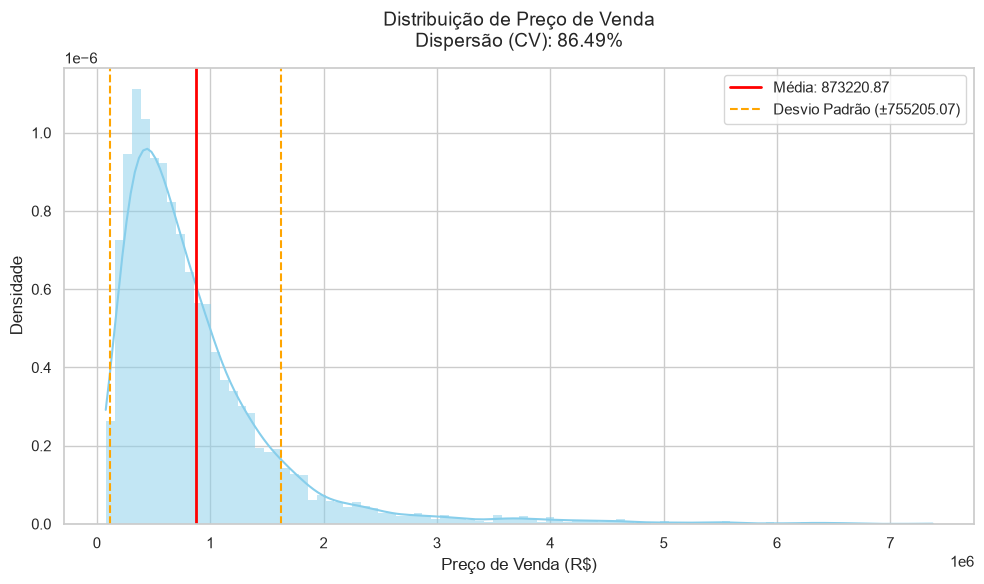

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configura o estilo do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 1. Plota o histograma com a curva de densidade (KDE)
sns.histplot(df['preco_venda'], kde=True, color="skyblue", stat="density", linewidth=0)

# 2. Linha vertical para a Média
plt.axvline(mean_val, color="red", linestyle="-", linewidth=2, 
            label=f"Média: {mean_val:.2f}")

# 3. Linhas verticais para o Desvio Padrão (Média ± Desvio Padrão)
plt.axvline(mean_val - std_val, color="orange", linestyle="--", linewidth=1.5, 
            label=f"Desvio Padrão (±{std_val:.2f})")
plt.axvline(mean_val + std_val, color="orange", linestyle="--", linewidth=1.5)

# Personalização de títulos e legendas
plt.title(f"Distribuição de Preço de Venda\nDispersão (CV): {dispersao:.2f}%", fontsize=14, pad=15)
plt.xlabel("Preço de Venda (R$)", fontsize=12)
plt.ylabel("Densidade", fontsize=12)
plt.legend(loc="upper right")

# Exibe o gráfico
plt.tight_layout()
plt.show()


O teste de normalidade(SHARPIRO - WILK) para uma relação aplicada ao mercado imobiliário com  *p-valor* menor que 0.05 ou seja, **não normal**
é aceitável, pois variáveis categóricas como a região, fazem a média sofrer muita alteração;

- Logo, ele não é o único teste a ser aplicado quando temos essas características


**Correlação - Matriz de PEARSON**
PEARSON --> Mede a **FORÇA** entre as variáveis **numéricas** (-1 a 1)

Mede quão próximas as variáveis estão a medida que cada uma se altera

**Força da correlação:**

0.9 a 1.0: Muito forte\
0.7 a 0.9: Forte\
0.5 a 0.7: Moderada\
0.3 a 0.5: Fraca\
0.0 a 0.3: Irrelevante ou inexistente

Se a correlação for alta > que 0.75 então o modelo de ML candidato de Árvores deve ser considerado.

**Teste de relevância das categorias-ANOVA**

Analisa as variáveis categóricas, como bairro, estado, etc entre outras variáveis categóricas
- O target(alvo) realmente muda em função dessas variáveis ou é só coincidência?

*p-valor* >= 0.05 **SEM IMPACTO** Então, a coluna da tabela pode ser descartada antes de treinar o modelo\
*p-valor* < 0.05 **IMPACTO SIGNIFICATIVO**  A categoria é indispensável logo, um modelo de árvore será melhor do que um modelo linar quando houver muitas categorias (Bairros, ciadades,etc)


**RESUMO da Técnica**\
ANALISE EXPLORATORIA DOS DADOS:\
TESTES INICIAIS --- TIPAGEM --- NULOS --- RESUMO ESTATISTICO

TESTES ESTATÍSTICOS NA FASE EXPLORATÓRIA:

TESTE 1---SHAPIRO WILK >>>>>>> VERIFICA a DISTRIBUIÇÃO DA VARIÁVEL NUMÉRICA SE RESULTADO > 0.05 = NORMAL --- Regressão Linear Bom Modelo Candidato

TESTE 2---PEARSON >>>>>>>>>>>> VERIFICA CORRELAÇÃO NUMÉRICA  ----- > 0.75 FORTE --- Regressão Linear  Aplicável

TESTE 3 --ANOVA >>>>>>>>>>>>>> VERIFICA RELEVANCIA CATEGORICA relacionada à variável Numérica SE < 0.05 Regressão Linear  aplicável 

TESTE 4 -- GRAFICO --- CONFIRMA VISUALMENTE OS TESTES ESTATÍSTICOS

Os 4 testes estatísticos **Não são obrigatórios** para a escolha do modelo, mas **recomendados** na fase **Exploração dos Dados**
pois nos ajudam a embasar a escolha de **modelos candidatos** de forma mais fundamentada.\
Os testes são instrumentos de diagnóstico e compreensão dos dados e não como sequência obrigatória para esclha do algoritimo.

EDA → gera evidências para formular hipóteses sobre os modelos.

Validação → testa se essas hipóteses realmente funcionam.
**A escolha final deve ser sustentada pelo desempenho dos modelos em validação.**